# 💊 Pharmacy-Level Invoice & Revenue Analysis
**Pharmaceutical Sales Dataset — Senior Data Analyst Report**

> All pharmacy names have been consolidated through entity-resolution into canonical names.  
> This notebook performs a complete pharmacy-centric revenue view covering invoice attribution, supplier breakdown, and business insights.

---
## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Overview & Quality Check](#2-data-overview--quality-check)
3. [Invoice-Level Aggregation](#3-invoice-level-aggregation)
4. [Pharmacy Summary Table](#4-pharmacy-summary-table)
5. [Pharmacy–Supplier Revenue Table](#5-pharmacysupplier-revenue-table)
6. [Pharmacy Invoice Detail Table](#6-pharmacy-invoice-detail-table)
7. [Insights & Business Analysis](#7-insights--business-analysis)
8. [Visualizations](#8-visualizations)
9. [Export Deliverables](#9-export-deliverables)


## 1. Setup & Data Loading

In [1]:
# Install any missing libraries
import subprocess, sys
for pkg in ["pandas", "numpy", "matplotlib", "seaborn", "squarify"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Try to import squarify (treemap); gracefully skip if unavailable ──
try:
    import squarify
    HAS_SQUARIFY = True
except ImportError:
    HAS_SQUARIFY = False
    print("squarify not available — treemap will be skipped. Install with: pip install squarify")

# ── Plot style ──
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_colwidth", 60)
print("Libraries loaded ✓")


Libraries loaded ✓


In [3]:
# ── Load the dataset ──
FILE_PATH = "updated16_file.csv"   # adjust path if needed

df = pd.read_csv(FILE_PATH)
print(f"Dataset shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
df.head(3)


Dataset shape : (10000, 22)
Columns       : ['id', 'supplier_id', 'invoice_id', 'prod_id', 'product_name', 'quantity', 'discount', 'total_amount', 'account_id', 'account_name', 'account_address', 'user_id', 'user_name', 'employee_name', 'city', 'region', 'area', 'area_id', 'creation_date', 'created_at', 'branch_code', 'Global_Account_ID']


,id,supplier_id,invoice_id,prod_id,product_name,quantity,discount,total_amount,account_id,account_name,account_address,user_id,user_name,employee_name,city,region,area,area_id,creation_date,created_at,branch_code,Global_Account_ID
0,48652728,59,32259,7,سيبروسين مرهم س ج,10,15.00,178.50,637,صيدليه مها مديريه امن الجيزه ش,كوبري الجلاء ميدان فيني الدقي,6,نهى الدالى,نهى الدالى,الجيزة,القاهرة الكبرى,الجيزة,17.00,2025-05-25 13:43:10,2026-05-19 16:29:03,3.00,GLB_0001
1,48652935,59,32281,7,سيبروسين مرهم س ج,3,15.00,53.55,4365,صيدليه السعدني فيصل,شارع مصرف جلال خلف فندق قاعود بجوار مسجد,6,نهى الدالى,نهى الدالى,الجيزة,القاهرة الكبرى,فيصل,99.00,2025-05-25 14:35:04,2026-05-19 16:29:03,2.00,GLB_0002
2,48653089,59,32301,7,سيبروسين مرهم س ج,2,21.00,33.18,3297,صيدليه مني احمد امبابه,شارع جمال عبد الناصر امام مدرسه تبارك الخاصه,137,اسماء رجب,اسماء رجب,الجيزة,القاهرة الكبرى,إمبابة,9.00,2025-05-25 15:21:21,2026-05-19 16:29:03,4.00,GLB_0003


## 2. Data Overview & Quality Check

In [4]:
# Basic info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10000 non-null  int64  
 1   supplier_id        10000 non-null  int64  
 2   invoice_id         10000 non-null  int64  
 3   prod_id            10000 non-null  int64  
 4   product_name       10000 non-null  str    
 5   quantity           10000 non-null  int64  
 6   discount           10000 non-null  float64
 7   total_amount       10000 non-null  float64
 8   account_id         10000 non-null  int64  
 9   account_name       10000 non-null  str    
 10  account_address    7440 non-null   str    
 11  user_id            10000 non-null  int64  
 12  user_name          9488 non-null   str    
 13  employee_name      10000 non-null  str    
 14  city               7004 non-null   str    
 15  region             7004 non-null   str    
 16  area               7004 non-null  

In [5]:
# Null counts
null_report = df.isnull().sum().to_frame("null_count")
null_report["null_%"] = (null_report["null_count"] / len(df) * 100).round(2)
null_report[null_report["null_count"] > 0]


,null_count,null_%
account_address,2560,25.60
user_name,512,5.12
city,2996,29.96
region,2996,29.96
area,2996,29.96
area_id,2996,29.96
branch_code,4278,42.78


In [6]:
# Key cardinalities
print(f"Unique pharmacies (account_name) : {df['account_name'].nunique():,}")
print(f"Unique invoice IDs               : {df['invoice_id'].nunique():,}")
print(f"Unique suppliers (supplier_id)   : {df['supplier_id'].nunique():,}")
print(f"Unique products                  : {df['product_name'].nunique():,}")
print(f"Date range (creation_date)       : {df['creation_date'].min()} → {df['creation_date'].max()}")


Unique pharmacies (account_name) : 1,085
Unique invoice IDs               : 2,937
Unique suppliers (supplier_id)   : 10
Unique products                  : 5,043
Date range (creation_date)       : 0000-00-00 00:00:00 → 2026-06-04 11:12:03


In [7]:
# Numeric summary
df[["quantity", "discount", "total_amount"]].describe()


,quantity,discount,total_amount
count,"10,000.00","10,000.00","10,000.00"
mean,4.49,25.36,259.32
std,30.92,9.12,"2,909.37"
min,0.00,0.00,0.00
25%,1.00,20.00,49.68
50%,2.00,26.00,100.80
75%,4.00,31.00,196.18
max,"1,354.00",88.00,"186,368.00"


## 3. Invoice-Level Aggregation

Each invoice may contain multiple product rows.  
We collapse to **(invoice_id, account_name, supplier_id, creation_date)** level,  
summing `total_amount` to get a single invoice-value per pharmacy–supplier combination.


In [8]:
# ── Build invoice-level table ──
invoice_df = (
    df.groupby(["invoice_id", "account_name", "supplier_id", "creation_date"], as_index=False)
    .agg(invoice_amount=("total_amount", "sum"))
)

# Sanity: invoices that span multiple pharmacies/suppliers exist — handled correctly above
multi_pharm = df.groupby("invoice_id")["account_name"].nunique()
print(f"Invoices spanning >1 pharmacy  : {(multi_pharm > 1).sum()}")
print(f"Invoice-level rows             : {len(invoice_df):,}")
print(f"Unique invoices confirmed       : {invoice_df['invoice_id'].nunique():,}")

TOTAL_REVENUE = invoice_df["invoice_amount"].sum()
print(f"Total dataset revenue          : EGP {TOTAL_REVENUE:,.2f}")
invoice_df.head(5)


Invoices spanning >1 pharmacy  : 119
Invoice-level rows             : 3,122
Unique invoices confirmed       : 2,937
Total dataset revenue          : EGP 2,593,247.27


,invoice_id,account_name,supplier_id,creation_date,invoice_amount
0,1,صيدليه المحور ارض اللواء,69,2025-08-05 21:35:48,"2,234.34"
1,1,صيدليه هاجر عامر الكفر,60,2024-12-01 21:27:56,547.10
2,2,صيدليه الدكروري السيده زينب,60,2024-12-01 21:33:16,"7,547.54"
3,2,صيدليه لايف الدقي,69,2025-08-05 21:36:44,"2,520.70"
4,3,ش المصريه الدوائيه الجيزه,60,2024-12-01 21:34:37,637.90


## 4. Pharmacy Summary Table

In [9]:
# ── Aggregate to pharmacy level ──
pharmacy_summary = (
    invoice_df.groupby("account_name", as_index=False)
    .agg(
        num_invoices    = ("invoice_id",     "nunique"),
        total_revenue   = ("invoice_amount", "sum"),
        avg_invoice     = ("invoice_amount", "mean"),
        min_invoice     = ("invoice_amount", "min"),
        max_invoice     = ("invoice_amount", "max"),
    )
)

pharmacy_summary["revenue_contribution_%"] = (
    pharmacy_summary["total_revenue"] / TOTAL_REVENUE * 100
).round(4)

pharmacy_summary["revenue_rank"] = (
    pharmacy_summary["total_revenue"]
    .rank(ascending=False, method="min")
    .astype(int)
)

pharmacy_summary = (
    pharmacy_summary
    .sort_values("revenue_rank")
    .reset_index(drop=True)
    .rename(columns={
        "account_name":          "Pharmacy Name",
        "num_invoices":          "Number of Invoices",
        "total_revenue":         "Total Revenue",
        "avg_invoice":           "Average Invoice Value",
        "min_invoice":           "Minimum Invoice Value",
        "max_invoice":           "Maximum Invoice Value",
        "revenue_contribution_%":"Revenue Contribution %",
        "revenue_rank":          "Revenue Rank",
    })
)

print(f"Pharmacy Summary Table — {len(pharmacy_summary):,} pharmacies")
pharmacy_summary.head(15)


Pharmacy Summary Table — 1,085 pharmacies


,Pharmacy Name,Number of Invoices,Total Revenue,Average Invoice Value,Minimum Invoice Value,Maximum Invoice Value,Revenue Contribution %,Revenue Rank
0,فارم احمد عبدالله المنصوره,2,"372,736.00","186,368.00","186,368.00","186,368.00",14.37,1
1,صيدليه ياسر فتحي فيصل توصيل م س,176,"250,230.96","1,421.77",41.40,"5,929.46",9.65,2
2,عميل مخزن الجمله,2,"228,749.77","114,374.88","1,094.40","227,655.37",8.82,3
3,مخزن الامراء,9,"120,148.28","13,349.81","3,960.00","20,808.00",4.63,4
4,الاصدقاء العريش,22,"98,742.45","4,488.29",479.20,"10,700.54",3.81,5
5,صيدليه هبه ابو زارع المنيب,8,"98,077.85","12,259.73",716.85,"31,280.00",3.78,6
6,حسام محمود,32,"75,084.76","2,346.40",21.28,"5,639.38",2.90,7
7,صيدليه الحصري الصفا والمروه,20,"67,043.86","3,352.19","1,114.06","6,784.94",2.59,8
8,صيدليه نقدي الموظفين,157,"52,539.90",334.65,17.68,"2,664.00",2.03,9
9,صيدليه نشوي,8,"46,413.64","5,801.70","1,873.90","17,882.26",1.79,10


In [10]:
# Quick stats on the summary
pharmacy_summary["Total Revenue"].describe()


count     1,085.00
mean      2,390.09
std      16,870.55
min           5.28
25%          39.78
50%         129.53
75%       1,014.62
max     372,736.00
Name: Total Revenue, dtype: float64

## 5. Pharmacy–Supplier Revenue Table

In [11]:
# ── Aggregate to pharmacy × supplier level ──
pharm_sup = (
    invoice_df.groupby(["account_name", "supplier_id"], as_index=False)
    .agg(
        num_invoices       = ("invoice_id",     "nunique"),
        revenue_from_sup   = ("invoice_amount", "sum"),
    )
)

# Pharmacy totals for % calculation
pharm_totals = (
    invoice_df.groupby("account_name")["invoice_amount"].sum()
    .rename("pharm_total")
    .reset_index()
)

pharm_sup = pharm_sup.merge(pharm_totals, on="account_name")
pharm_sup["supplier_revenue_%"] = (
    pharm_sup["revenue_from_sup"] / pharm_sup["pharm_total"] * 100
).round(4)

pharm_sup["supplier_rank"] = (
    pharm_sup.groupby("account_name")["revenue_from_sup"]
    .rank(ascending=False, method="min")
    .astype(int)
)

pharm_sup = (
    pharm_sup
    .sort_values(["account_name", "supplier_rank"])
    .drop(columns="pharm_total")
    .reset_index(drop=True)
    .rename(columns={
        "account_name":       "Pharmacy Name",
        "supplier_id":        "Supplier Name",
        "num_invoices":       "Number of Invoices",
        "revenue_from_sup":   "Revenue from Supplier",
        "supplier_revenue_%": "Supplier Revenue %",
        "supplier_rank":      "Supplier Rank within Pharmacy",
    })
)

print(f"Pharmacy–Supplier Table — {len(pharm_sup):,} rows")
pharm_sup.head(15)


Pharmacy–Supplier Table — 1,100 rows


,Pharmacy Name,Supplier Name,Number of Invoices,Revenue from Supplier,Supplier Revenue %,Supplier Rank within Pharmacy
0,ا حسام عبد اللطيف,76,10,"5,655.23",100.00,1
1,ابانوب رمزي الجديده عمرانيه ن س,73,1,70.40,100.00,1
2,ابانوب سمير العجوزه ن س,73,1,12.87,100.00,1
3,ابتسام حربي نهي سابقا كفر حكيم,73,2,112.53,100.00,1
4,ابرام هاني الهرم ن س,73,2,46.72,100.00,1
5,ابراهيم سعد موظف,76,1,20.25,100.00,1
6,ابراهيم سعيد صفط,73,1,35.20,100.00,1
7,ابراهيم لبيب العمرانيه,73,1,28.56,100.00,1
8,ابو السعود ش زغلول,73,1,76.65,100.00,1
9,ابو السعود كرداسه,73,3,56.37,100.00,1


## 6. Pharmacy Invoice Detail Table

In [25]:
pharm_invoice_detail = (
    invoice_df
    .rename(columns={
        "account_name":   "Pharmacy Name",
        "invoice_id":     "Invoice ID",
        "creation_date":  "Invoice Date",
        "supplier_id":    "Supplier Name",
        "invoice_amount": "Invoice Amount",
    })
    .sort_values(["Pharmacy Name", "Invoice ID"])
    .reset_index(drop=True)
)

print(f"Invoice Detail Table — {len(pharm_invoice_detail):,} rows")
pharm_invoice_detail.head(11)


Invoice Detail Table — 3,122 rows


,Invoice ID,Pharmacy Name,Supplier Name,Invoice Date,Invoice Amount
0,257,ا حسام عبد اللطيف,76,2022-07-07 13:55:28,770.72
1,4932,ا حسام عبد اللطيف,76,2022-09-20 16:10:11,892.72
2,4935,ا حسام عبد اللطيف,76,2022-09-20 16:27:37,262.86
3,5183,ا حسام عبد اللطيف,76,2022-09-24 13:08:04,114.55
4,11107,ا حسام عبد اللطيف,76,2022-12-07 16:07:12,"1,176.33"
5,11192,ا حسام عبد اللطيف,76,2022-12-08 16:38:38,162.06
6,13224,ا حسام عبد اللطيف,76,2023-01-08 13:00:43,401.27
7,16658,ا حسام عبد اللطيف,76,2023-03-06 14:21:16,"1,206.68"
8,32199,ا حسام عبد اللطيف,76,2023-10-26 15:41:07,553.50
9,32205,ا حسام عبد اللطيف,76,2023-10-26 16:01:01,114.54


In [27]:
# ── Helper: look up a specific pharmacy ──
def pharmacy_lookup(name: str):
    """Print all invoices for a named pharmacy."""
    result = pharm_invoice_detail[pharm_invoice_detail["Pharmacy Name"] == name]
    if result.empty:
        print(f"No records found for: {name}")
        return
    print(f"=== {name} ===")
    print(f"Invoices : {result['Invoice ID'].nunique()}")
    print(f"Revenue  : EGP {result['Invoice Amount'].sum():,.2f}")
    display(result)

# Example — replace with any pharmacy name from your dataset
example_name = pharmacy_summary["Pharmacy Name"].iloc[5]
pharmacy_lookup(example_name)


=== صيدليه هبه ابو زارع المنيب ===
Invoices : 8
Revenue  : EGP 98,077.85


,Invoice ID,Pharmacy Name,Supplier Name,Invoice Date,Invoice Amount
2265,27247,صيدليه هبه ابو زارع المنيب,76,2023-08-14 21:05:41,"2,227.17"
2266,27309,صيدليه هبه ابو زارع المنيب,76,2023-08-15 20:14:39,716.85
2267,27605,صيدليه هبه ابو زارع المنيب,76,2023-08-21 20:57:19,"1,160.19"
2268,54870,صيدليه هبه ابو زارع المنيب,76,2024-09-30 15:20:59,"27,360.00"
2269,55302,صيدليه هبه ابو زارع المنيب,76,2024-10-06 15:25:36,"11,244.96"
2270,59347,صيدليه هبه ابو زارع المنيب,76,2024-11-24 13:23:15,"14,386.68"
2271,60000,صيدليه هبه ابو زارع المنيب,76,2024-12-02 13:38:07,"31,280.00"
2272,60127,صيدليه هبه ابو زارع المنيب,76,2024-12-03 16:18:19,"9,702.00"


## 7. Insights & Business Analysis

In [29]:
# ── 7.1 Top 10 Pharmacies by Revenue ──
top10 = pharmacy_summary.head(10)
print("Top 10 Pharmacies by Revenue")
print("=" * 60)
display(top10[["Pharmacy Name","Total Revenue","Revenue Contribution %","Revenue Rank"]])
print(f"\n✦ Top 10 account for {top10['Revenue Contribution %'].sum():.2f}% of total revenue")


Top 10 Pharmacies by Revenue


,Pharmacy Name,Total Revenue,Revenue Contribution %,Revenue Rank
0,فارم احمد عبدالله المنصوره,"372,736.00",14.37,1
1,صيدليه ياسر فتحي فيصل توصيل م س,"250,230.96",9.65,2
2,عميل مخزن الجمله,"228,749.77",8.82,3
3,مخزن الامراء,"120,148.28",4.63,4
4,الاصدقاء العريش,"98,742.45",3.81,5
5,صيدليه هبه ابو زارع المنيب,"98,077.85",3.78,6
6,حسام محمود,"75,084.76",2.90,7
7,صيدليه الحصري الصفا والمروه,"67,043.86",2.59,8
8,صيدليه نقدي الموظفين,"52,539.90",2.03,9
9,صيدليه نشوي,"46,413.64",1.79,10



✦ Top 10 account for 54.36% of total revenue


In [15]:
# ── 7.2 Top Suppliers Across All Pharmacies ──
top_suppliers = (
    invoice_df.groupby("supplier_id")["invoice_amount"]
    .sum().sort_values(ascending=False)
    .reset_index()
    .rename(columns={"supplier_id":"Supplier ID","invoice_amount":"Total Revenue"})
)
top_suppliers["Revenue %"] = (top_suppliers["Total Revenue"] / TOTAL_REVENUE * 100).round(2)
top_suppliers["Revenue Rank"] = range(1, len(top_suppliers)+1)
print("Top Suppliers — Dataset-Wide")
display(top_suppliers)


Top Suppliers — Dataset-Wide


,Supplier ID,Total Revenue,Revenue %,Revenue Rank
0,80,"595,473.18",22.96,1
1,76,"458,462.32",17.68,2
2,72,"347,987.94",13.42,3
3,75,"329,084.77",12.69,4
4,63,"252,679.28",9.74,5
5,67,"182,541.46",7.04,6
6,69,"169,811.11",6.55,7
7,60,"142,227.64",5.48,8
8,59,"77,241.12",2.98,9
9,73,"37,738.45",1.46,10


In [16]:
# ── 7.3 Supplier Concentration vs Diversification ──
supplier_count = invoice_df.groupby("account_name")["supplier_id"].nunique().rename("num_suppliers")

print("Pharmacies using only 1 supplier (highly concentrated):")
display(supplier_count[supplier_count == 1].reset_index().rename(columns={"account_name":"Pharmacy Name"}))

print(f"\nMost diversified pharmacies (top 10 by supplier count):")
display(
    supplier_count.sort_values(ascending=False).head(10)
    .reset_index().rename(columns={"account_name":"Pharmacy Name","num_suppliers":"# Suppliers"})
)


Pharmacies using only 1 supplier (highly concentrated):


,Pharmacy Name,num_suppliers
0,ا حسام عبد اللطيف,1
1,ابانوب رمزي الجديده عمرانيه ن س,1
2,ابانوب سمير العجوزه ن س,1
3,ابتسام حربي نهي سابقا كفر حكيم,1
4,ابرام هاني الهرم ن س,1
...,...,...
1066,وليد كفر حكيم,1
1067,ياسر سمير محاسب,1
1068,يسرا عمر بولاق,1
1069,يمني حسن المهندسين اي سبلاي,1



Most diversified pharmacies (top 10 by supplier count):


,Pharmacy Name,# Suppliers
0,صيدليه الحريه ارض اللواء,3
1,صيدليه ترياق الهرم,2
2,صيدليه المروه ش الهرم,2
3,صيدليه دعاء الجديده بشتيل اي سبلاي,2
4,صيدليه خلود الحديثه استلام ارض اللواء,2
5,الصحه الجديده امبابه,2
6,صيدليه اسلام ابو,2
7,صيدليه ريتال البحر الاعظم,2
8,صيدليه ضياء الدين المعتمديه,2
9,صيدليه علاء شحاته النحاس بشتيل,2


In [17]:
# ── 7.4 Revenue Distribution Analysis ──
desc = pharmacy_summary["Total Revenue"].describe(percentiles=[.25,.5,.75,.9,.95,.99])
print("Revenue Distribution across Pharmacies")
print(desc.to_string())

# Pareto rule
ps = pharmacy_summary.sort_values("Total Revenue", ascending=False).copy()
ps["cum_revenue"] = ps["Total Revenue"].cumsum()
ps["cum_pct"]     = ps["cum_revenue"] / TOTAL_REVENUE * 100
n80 = int((ps["cum_pct"] <= 80).sum())
print(f"\n✦ Top {n80} pharmacies ({n80/len(ps)*100:.1f}%) generate 80% of revenue  [Pareto principle]")


Revenue Distribution across Pharmacies
count     1,085.00
mean      2,390.09
std      16,870.55
min           5.28
25%          39.78
50%         129.53
75%       1,014.62
90%       2,422.17
95%       5,320.10
99%      34,756.77
max     372,736.00

✦ Top 68 pharmacies (6.3%) generate 80% of revenue  [Pareto principle]


In [18]:
# ── 7.5 Disproportionately High Revenue Pharmacies (outlier detection) ──
mean_rev = pharmacy_summary["Total Revenue"].mean()
std_rev  = pharmacy_summary["Total Revenue"].std()
threshold = mean_rev + 2 * std_rev

outliers = pharmacy_summary[pharmacy_summary["Total Revenue"] > threshold]
print(f"Revenue threshold (mean + 2σ) : EGP {threshold:,.2f}")
print(f"Pharmacies above threshold    : {len(outliers)}")
display(outliers[["Pharmacy Name","Total Revenue","Revenue Contribution %","Revenue Rank"]])


Revenue threshold (mean + 2σ) : EGP 36,131.18
Pharmacies above threshold    : 11


,Pharmacy Name,Total Revenue,Revenue Contribution %,Revenue Rank
0,فارم احمد عبدالله المنصوره,"372,736.00",14.37,1
1,صيدليه ياسر فتحي فيصل توصيل م س,"250,230.96",9.65,2
2,عميل مخزن الجمله,"228,749.77",8.82,3
3,مخزن الامراء,"120,148.28",4.63,4
4,الاصدقاء العريش,"98,742.45",3.81,5
5,صيدليه هبه ابو زارع المنيب,"98,077.85",3.78,6
6,حسام محمود,"75,084.76",2.90,7
7,صيدليه الحصري الصفا والمروه,"67,043.86",2.59,8
8,صيدليه نقدي الموظفين,"52,539.90",2.03,9
9,صيدليه نشوي,"46,413.64",1.79,10


In [50]:
# 1. تحديد الصفوف التي تحتوي على "غادر العمل"
mask = df['employee_name'] == 'غادر العمل'

# 2. استرجاع الاسم الحقيقي من user_name وإضافة كلمة (سابق) لتمييزهم
df.loc[mask, 'employee_name'] = df.loc[mask, 'user_name'] + ' (سابق)'

# 3. إعادة حساب أفضل المناديب بعد التعديل (لاحظ: أزلنا سطر الـ fix_arabic من هنا)
top_reps = df.groupby('employee_name')['total_amount'].sum().nlargest(5).reset_index()

# طباعة النتيجة للتأكد (ستظهر الآن عربية طبيعية 100%)
print("الأسماء بعد التعديل والإنقاذ:")
print(top_reps['employee_name'].tolist())

الأسماء بعد التعديل والإنقاذ:
['محمد شعبان عبد الوهاب', 'اى سبلاى', 'هيثم محمود (سابق)', 'م جديد', 'SARA']


## 8. Visualizations

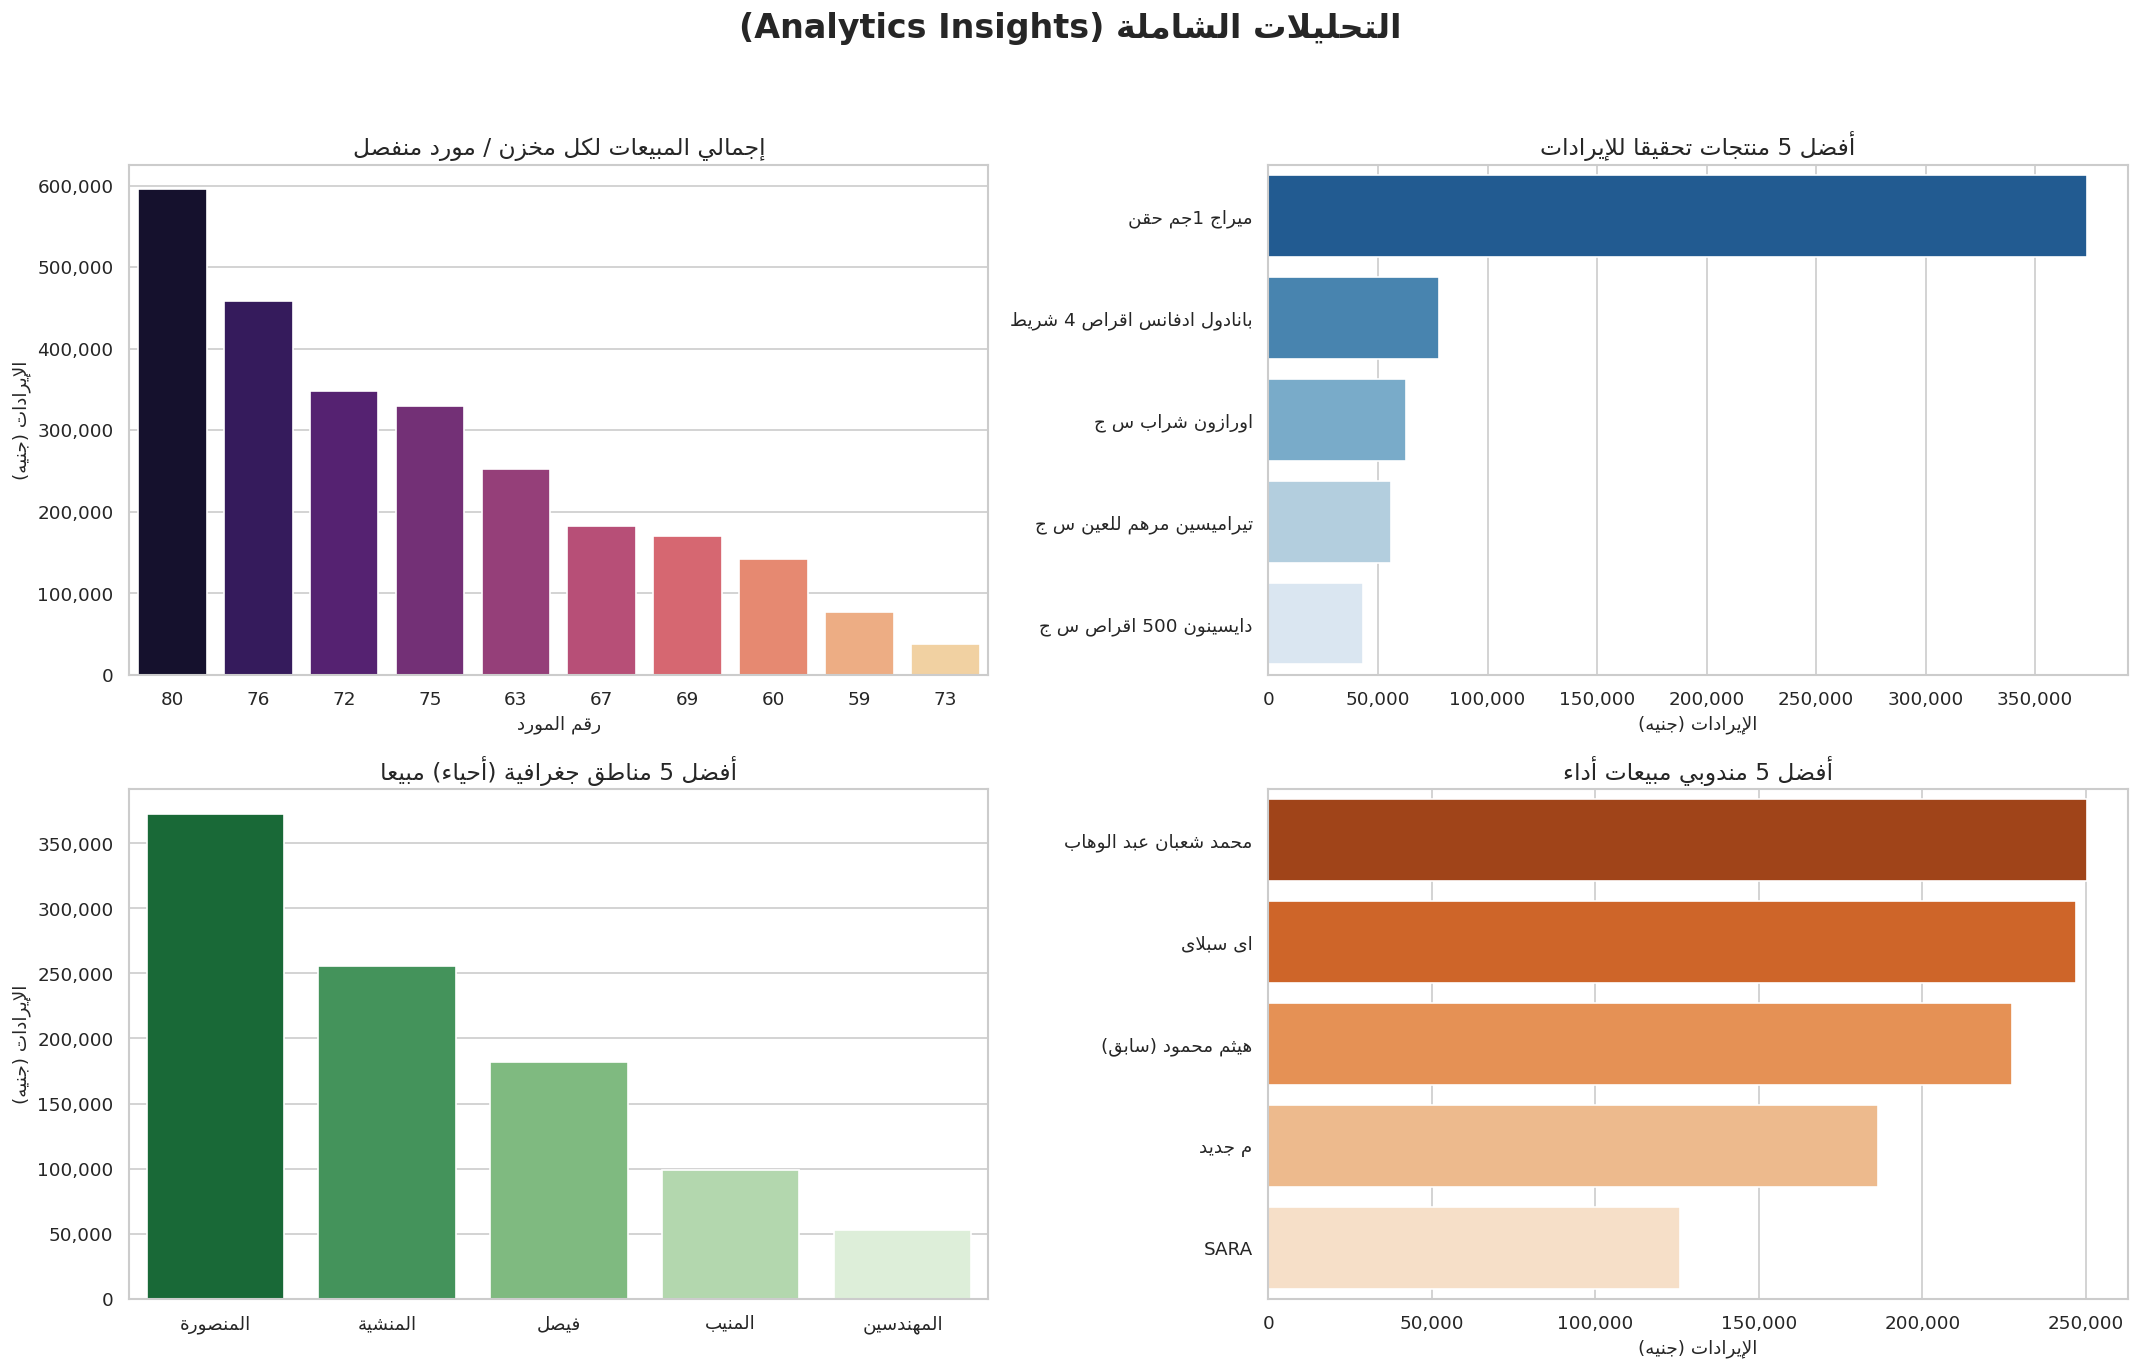

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic(text):
    return get_display(arabic_reshaper.reshape(str(text)))

# إعداد حجم الرسم ليكون مجمعاً (Subplots)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(fix_arabic('التحليلات الشاملة (Analytics Insights)'), fontsize=20, fontweight='bold')

# -------------------------------------------------------------------
# 1. تحليل كل مخزن على حدة (Analyze each warehouse separately)
# -------------------------------------------------------------------
warehouse_sales = df.groupby('supplier_id')['total_amount'].sum().reset_index()
warehouse_sales = warehouse_sales.sort_values('total_amount', ascending=False)
warehouse_sales['supplier_id'] = warehouse_sales['supplier_id'].astype(str) # لتحسين شكل المحور

sns.barplot(ax=axes[0, 0], data=warehouse_sales, x='supplier_id', y='total_amount', palette='magma')
axes[0, 0].set_title(fix_arabic('إجمالي المبيعات لكل مخزن / مورد منفصل'), fontsize=14)
axes[0, 0].set_ylabel(fix_arabic('الإيرادات (جنيه)'))
axes[0, 0].set_xlabel(fix_arabic('رقم المورد'))
axes[0, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# -------------------------------------------------------------------
# 2. أفضل المنتجات (Top Products)
# -------------------------------------------------------------------
top_products = df.groupby('product_name')['total_amount'].sum().nlargest(5).reset_index()
top_products['product_name'] = top_products['product_name'].apply(fix_arabic)

sns.barplot(ax=axes[0, 1], data=top_products, y='product_name', x='total_amount', palette='Blues_r')
axes[0, 1].set_title(fix_arabic('أفضل 5 منتجات تحقيقاً للإيرادات'), fontsize=14)
axes[0, 1].set_xlabel(fix_arabic('الإيرادات (جنيه)'))
axes[0, 1].set_ylabel('')
axes[0, 1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# -------------------------------------------------------------------
# 3. أفضل المناطق (Best-performing regions)
# -------------------------------------------------------------------
# بنستخدم عمود area اللي استخرجناه بذكاء في المرحلة الأولى
top_regions =df.groupby('area')['total_amount'].sum().nlargest(5).reset_index()
top_regions['area'] = top_regions['area'].apply(fix_arabic)

sns.barplot(ax=axes[1, 0], data=top_regions, x='area', y='total_amount', palette='Greens_r')
axes[1, 0].set_title(fix_arabic('أفضل 5 مناطق جغرافية (أحياء) مبيعاً'), fontsize=14)
axes[1, 0].set_ylabel(fix_arabic('الإيرادات (جنيه)'))
axes[1, 0].set_xlabel('')
axes[1, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# -------------------------------------------------------------------
# 4. أفضل مندوبي المبيعات (Top Sales Representatives)
# -------------------------------------------------------------------
# نستخدم employee_name بعد تنظيفه
top_reps = df.groupby('employee_name')['total_amount'].sum().nlargest(5).reset_index()
top_reps['employee_name'] = top_reps['employee_name'].apply(fix_arabic)

sns.barplot(ax=axes[1, 1], data=top_reps, y='employee_name', x='total_amount', palette='Oranges_r')
axes[1, 1].set_title(fix_arabic('أفضل 5 مندوبي مبيعات أداءً'), fontsize=14)
axes[1, 1].set_xlabel(fix_arabic('الإيرادات (جنيه)'))
axes[1, 1].set_ylabel('')
axes[1, 1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

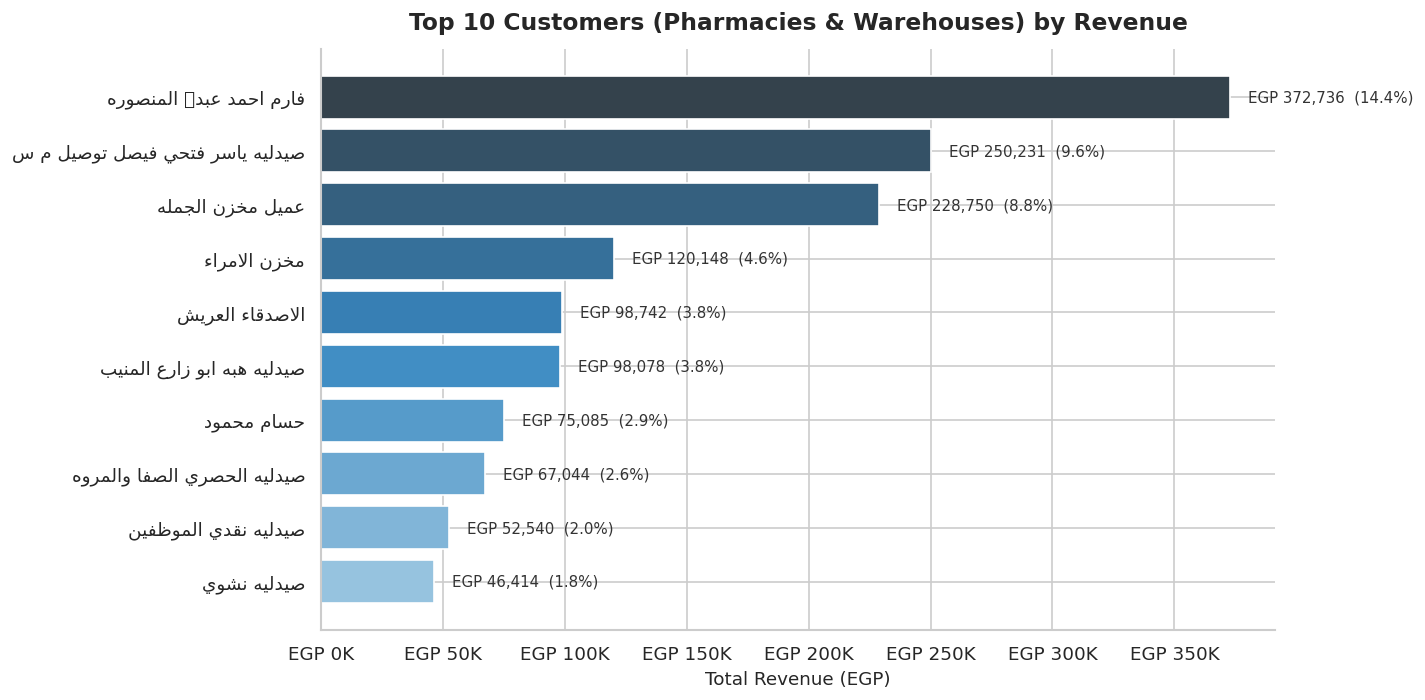

Saved: fig1_top10_bar.png


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import arabic_reshaper
from bidi.algorithm import get_display

# ── Fig 1: Top 10 Customers (Pharmacies/Warehouses) — Horizontal Bar Chart ──
fig, ax = plt.subplots(figsize=(12, 6))

top10_plot = pharmacy_summary.head(10).sort_values("Total Revenue")
colors = sns.color_palette("Blues_d", len(top10_plot))

# دالة لتصحيح النصوص العربية فقط (بدون حذف أي كلمات)
def reshape_arabic(text):
    reshaped_text = arabic_reshaper.reshape(str(text))
    return get_display(reshaped_text)

# تعديل أسماء العملاء في البيانات قبل الرسم
top10_plot["Pharmacy Name"] = top10_plot["Pharmacy Name"].apply(reshape_arabic)
bars = ax.barh(top10_plot["Pharmacy Name"], top10_plot["Total Revenue"], color=colors, edgecolor="white")

# إضافة النصوص (الأرقام والنسبة) بجانب كل شريط 
# (تم الاحتفاظ بضبط المسافة الديناميكية لتجنب تداخل الأرقام)
for bar, val, pct in zip(bars, top10_plot["Total Revenue"], top10_plot["Revenue Contribution %"]):
    ax.text(bar.get_width() + (top10_plot["Total Revenue"].max() * 0.02),
            bar.get_y() + bar.get_height() / 2,
            f"EGP {val:,.0f}  ({pct:.1f}%)",
            va="center", fontsize=9, color="#333")

# تعديل العناوين لتشمل الصيدليات والمخازن معاً
ax.set_xlabel("Total Revenue (EGP)", fontsize=11)
ax.set_title("Top 10 Customers (Pharmacies & Warehouses) by Revenue", fontsize=14, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"EGP {x/1e3:.0f}K"))
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig1_top10_bar.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: fig1_top10_bar.png")

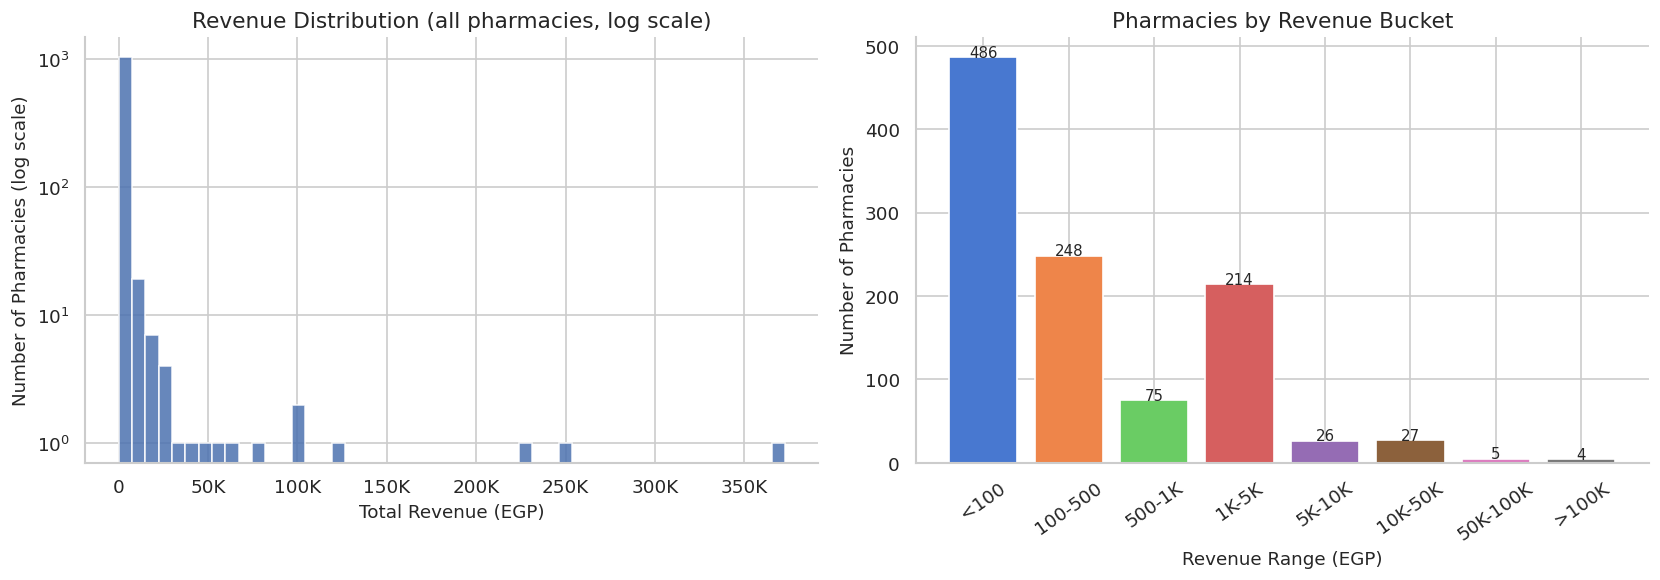

Saved: fig2_histogram.png


In [20]:
# ── Fig 2: Revenue Distribution Histogram ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram (all pharmacies)
ax = axes[0]
ax.hist(pharmacy_summary["Total Revenue"], bins=50, color="#4c72b0", edgecolor="white", alpha=0.85)
ax.set_yscale("log")
ax.set_xlabel("Total Revenue (EGP)")
ax.set_ylabel("Number of Pharmacies (log scale)")
ax.set_title("Revenue Distribution (all pharmacies, log scale)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K" if x >= 1000 else f"{x:.0f}"))
ax.spines[["top","right"]].set_visible(False)

# Revenue bucket bar chart
ax2 = axes[1]
bins   = [0, 100, 500, 1000, 5000, 10000, 50000, 100000, 1e9]
labels = ["<100","100-500","500-1K","1K-5K","5K-10K","10K-50K","50K-100K",">100K"]
pharmacy_summary["rev_bin"] = pd.cut(pharmacy_summary["Total Revenue"], bins=bins, labels=labels, right=True)
bin_counts = pharmacy_summary["rev_bin"].value_counts().reindex(labels)
ax2.bar(labels, bin_counts.values, color=sns.color_palette("muted", len(labels)), edgecolor="white")
for i, v in enumerate(bin_counts.values):
    ax2.text(i, v + 0.5, str(v), ha="center", fontsize=9)
ax2.set_xlabel("Revenue Range (EGP)")
ax2.set_ylabel("Number of Pharmacies")
ax2.set_title("Pharmacies by Revenue Bucket")
ax2.tick_params(axis="x", rotation=35)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig2_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_histogram.png")


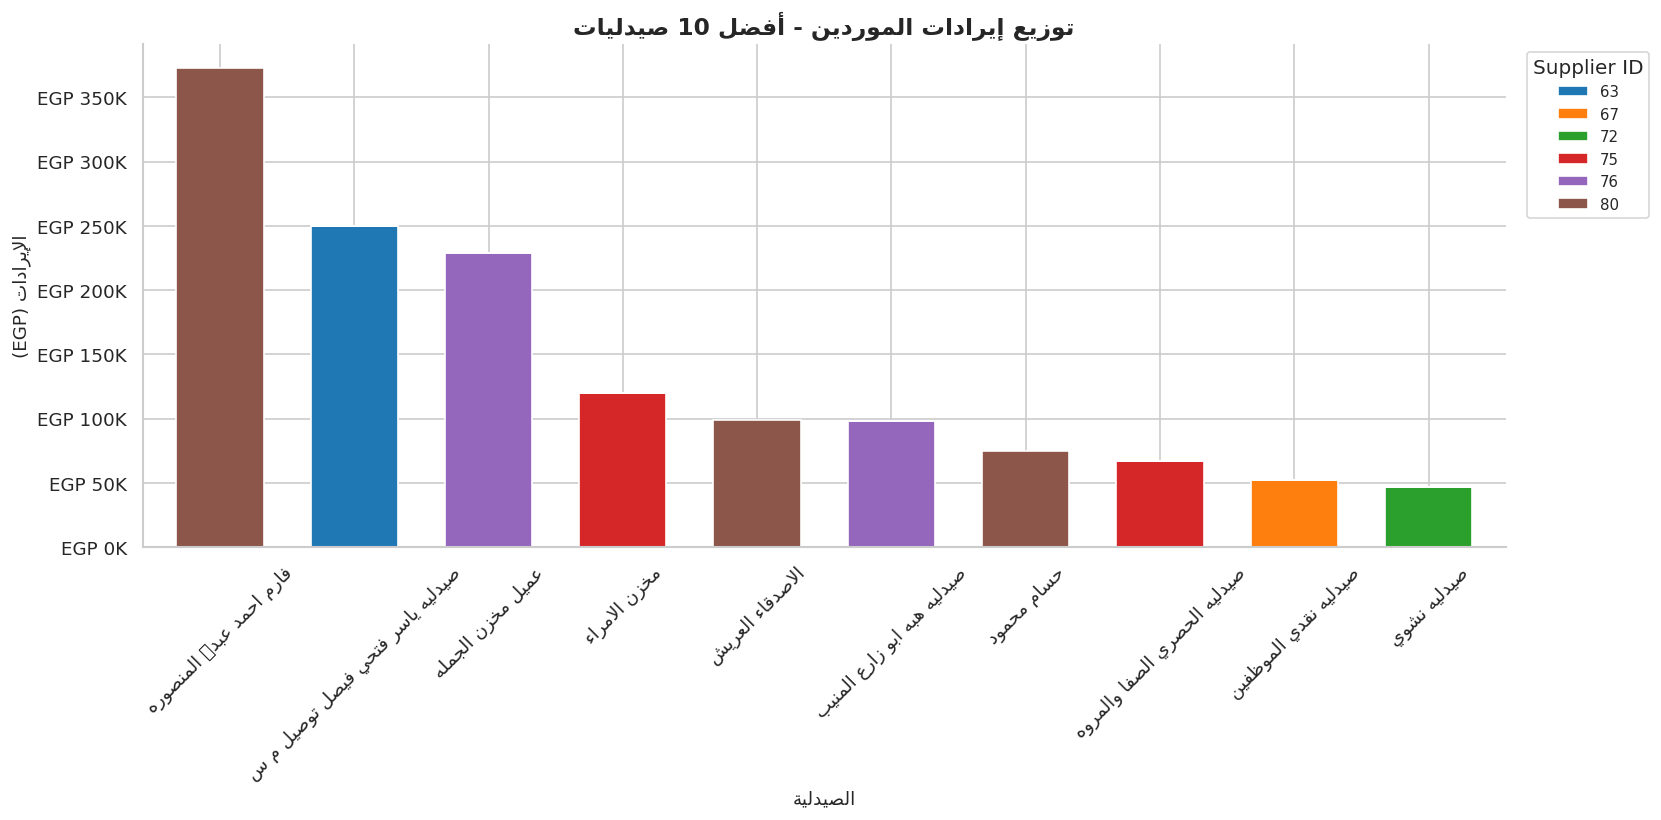

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import arabic_reshaper
from bidi.algorithm import get_display

# 1. إعداد الخط ليدعم العربية (اختر خطاً متوفراً على جهازك مثل Arial)
plt.rcParams['font.sans-serif'] = ['Arial']

# 2. دالة المعالجة
def get_arabic_text(text):
    reshaped_text = arabic_reshaper.reshape(str(text))
    return get_display(reshaped_text)

# 3. قبل الرسم، قم بتعديل أسماء الصيدليات في الـ Index
stacked_data.index = [get_arabic_text(name) for name in stacked_data.index]

# (إذا كنت تريد أيضاً تعديل عنوان الـ Legend)
# يمكنك القيام بذلك يدوياً إذا كانت الأسماء تحتاج لترجمة

# 4. الرسم
fig, ax = plt.subplots(figsize=(14, 7))
palette = sns.color_palette("tab10", len(stacked_data.columns))
stacked_data.plot(kind="bar", stacked=True, ax=ax, color=palette, edgecolor="white", width=0.65)

# 5. التنسيق
ax.set_xlabel(get_arabic_text("الصيدلية"), fontsize=11)
ax.set_ylabel(get_arabic_text("الإيرادات (EGP)"), fontsize=11)
ax.set_title(get_arabic_text("توزيع إيرادات الموردين - أفضل 10 صيدليات"), fontsize=14, fontweight="bold")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"EGP {x/1e3:.0f}K"))
ax.tick_params(axis="x", rotation=45) # زدت الزاوية لـ 45 لضمان عدم تداخل الأسماء
ax.legend(title="Supplier ID", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

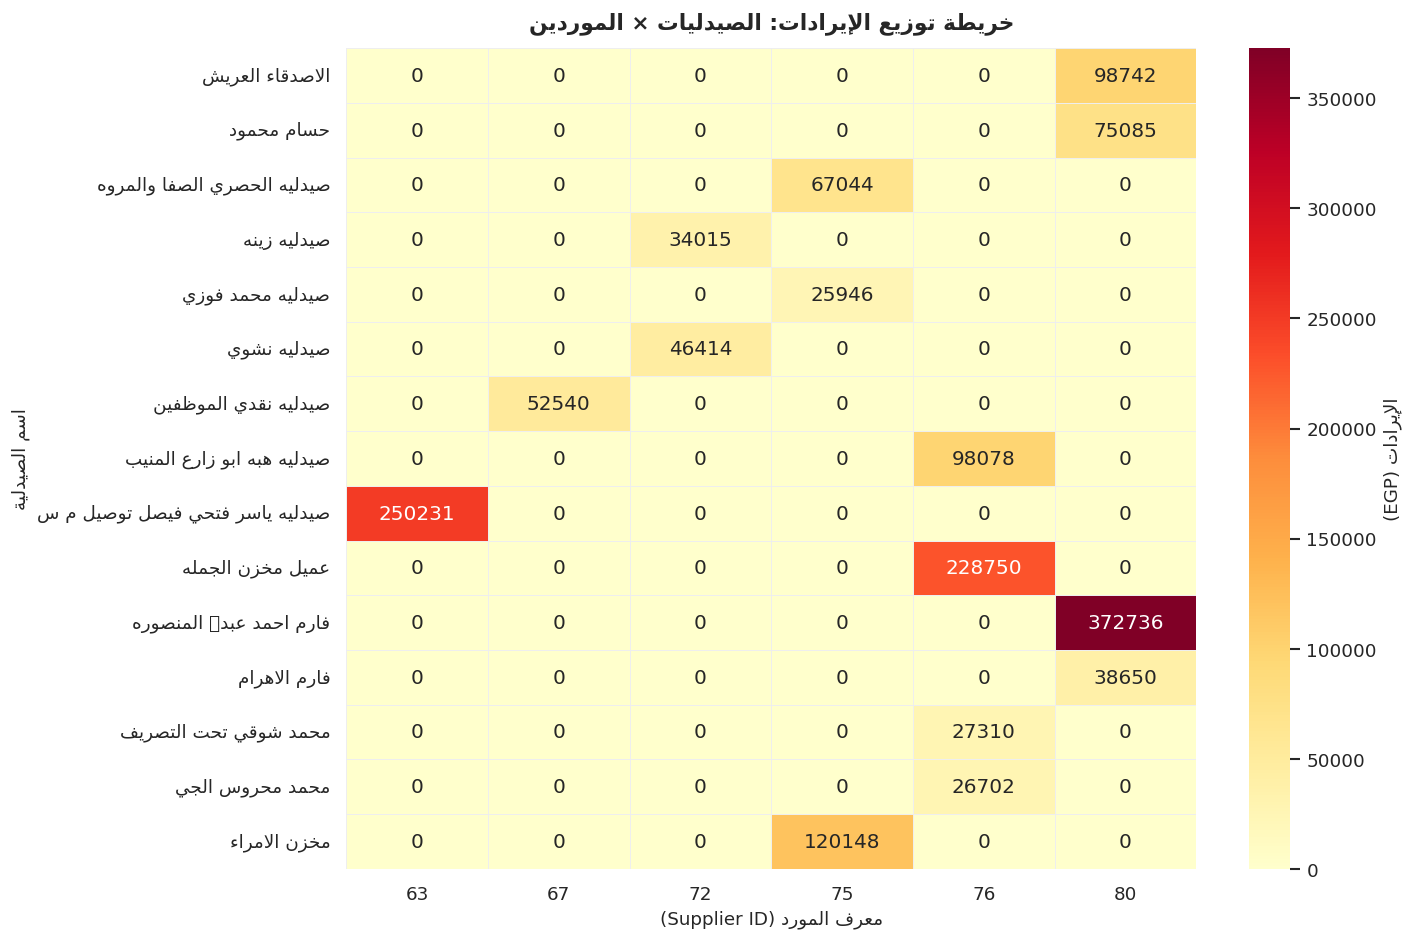

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

# 1. دالة المعالجة
def get_arabic_text(text):
    return get_display(arabic_reshaper.reshape(str(text)))

# 2. تطبيق المعالجة على أسماء الصيدليات (Index)
heatmap_data.index = [get_arabic_text(name) for name in heatmap_data.index]

# 3. إعداد الخط (تأكد من اختيار خط يدعم العربية)
plt.rcParams['font.sans-serif'] = ['Arial']

# 4. الرسم
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="#eee",
    ax=ax,
    cbar_kws={"label": get_arabic_text("الإيرادات (EGP)")},
)

# 5. التنسيق وتسمية المحاور
ax.set_title(get_arabic_text("خريطة توزيع الإيرادات: الصيدليات × الموردين"), fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel(get_arabic_text("معرف المورد (Supplier ID)"), fontsize=11)
ax.set_ylabel(get_arabic_text("اسم الصيدلية"), fontsize=11)

# ضبط المحاور
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("fig4_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

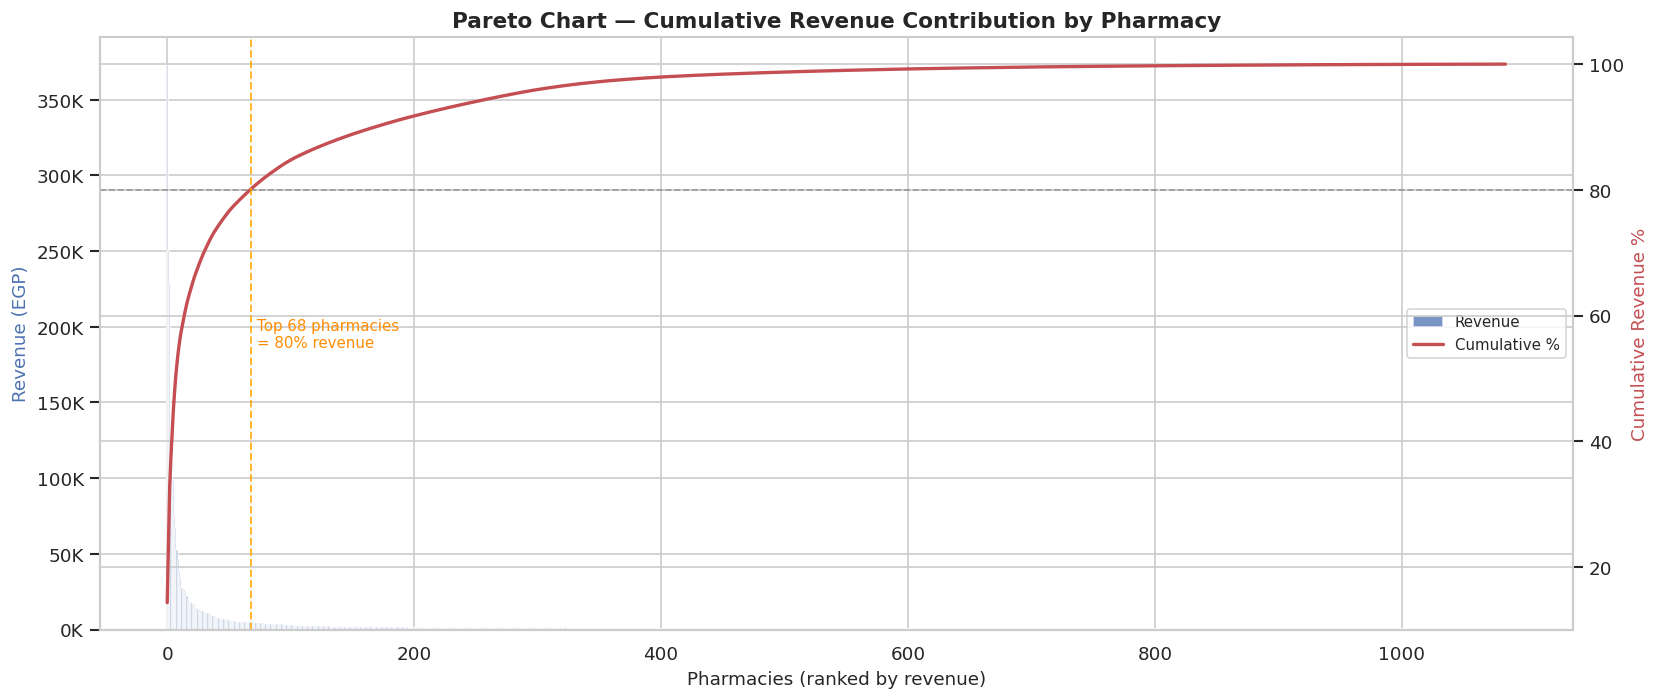

Saved: fig5_pareto.png


In [23]:
# ── Fig 5: Pareto Chart — Cumulative Revenue Contribution ──
pareto_df = pharmacy_summary.sort_values("Total Revenue", ascending=False).reset_index(drop=True)
pareto_df["cum_pct"] = pareto_df["Total Revenue"].cumsum() / TOTAL_REVENUE * 100

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

x = np.arange(len(pareto_df))
ax1.bar(x, pareto_df["Total Revenue"], color="#4c72b0", alpha=0.75, width=1.0, label="Revenue")
ax2.plot(x, pareto_df["cum_pct"], color="#c44e52", linewidth=2, label="Cumulative %")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1, alpha=0.7)

# Mark 80% point
n80 = int((pareto_df["cum_pct"] <= 80).sum())
ax2.axvline(n80, color="orange", linestyle="--", linewidth=1.2, alpha=0.8)
ax2.text(n80 + 5, 55, f"Top {n80} pharmacies\n= 80% revenue", fontsize=9, color="darkorange")

ax1.set_xlabel("Pharmacies (ranked by revenue)", fontsize=11)
ax1.set_ylabel("Revenue (EGP)", fontsize=11, color="#4c72b0")
ax2.set_ylabel("Cumulative Revenue %", fontsize=11, color="#c44e52")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax1.set_title("Pareto Chart — Cumulative Revenue Contribution by Pharmacy", fontsize=13, fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=9)
ax1.spines[["top"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig5_pareto.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig5_pareto.png")


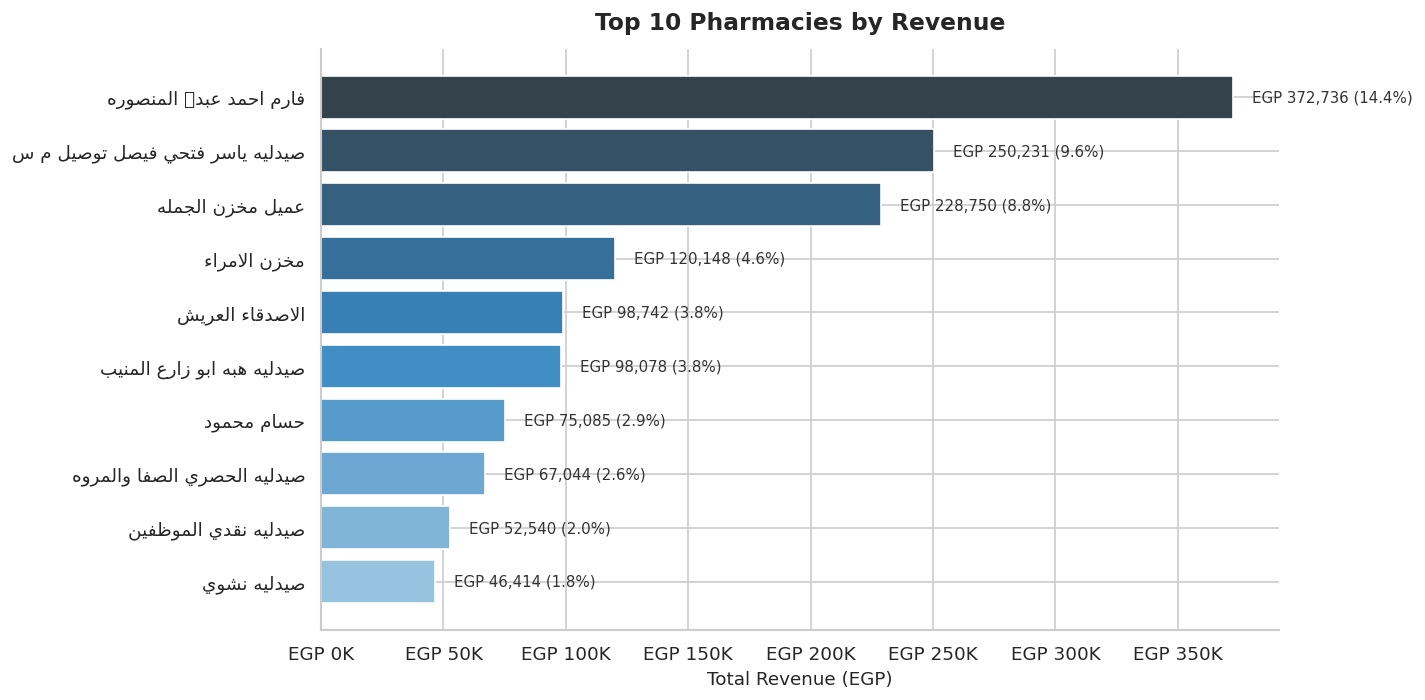

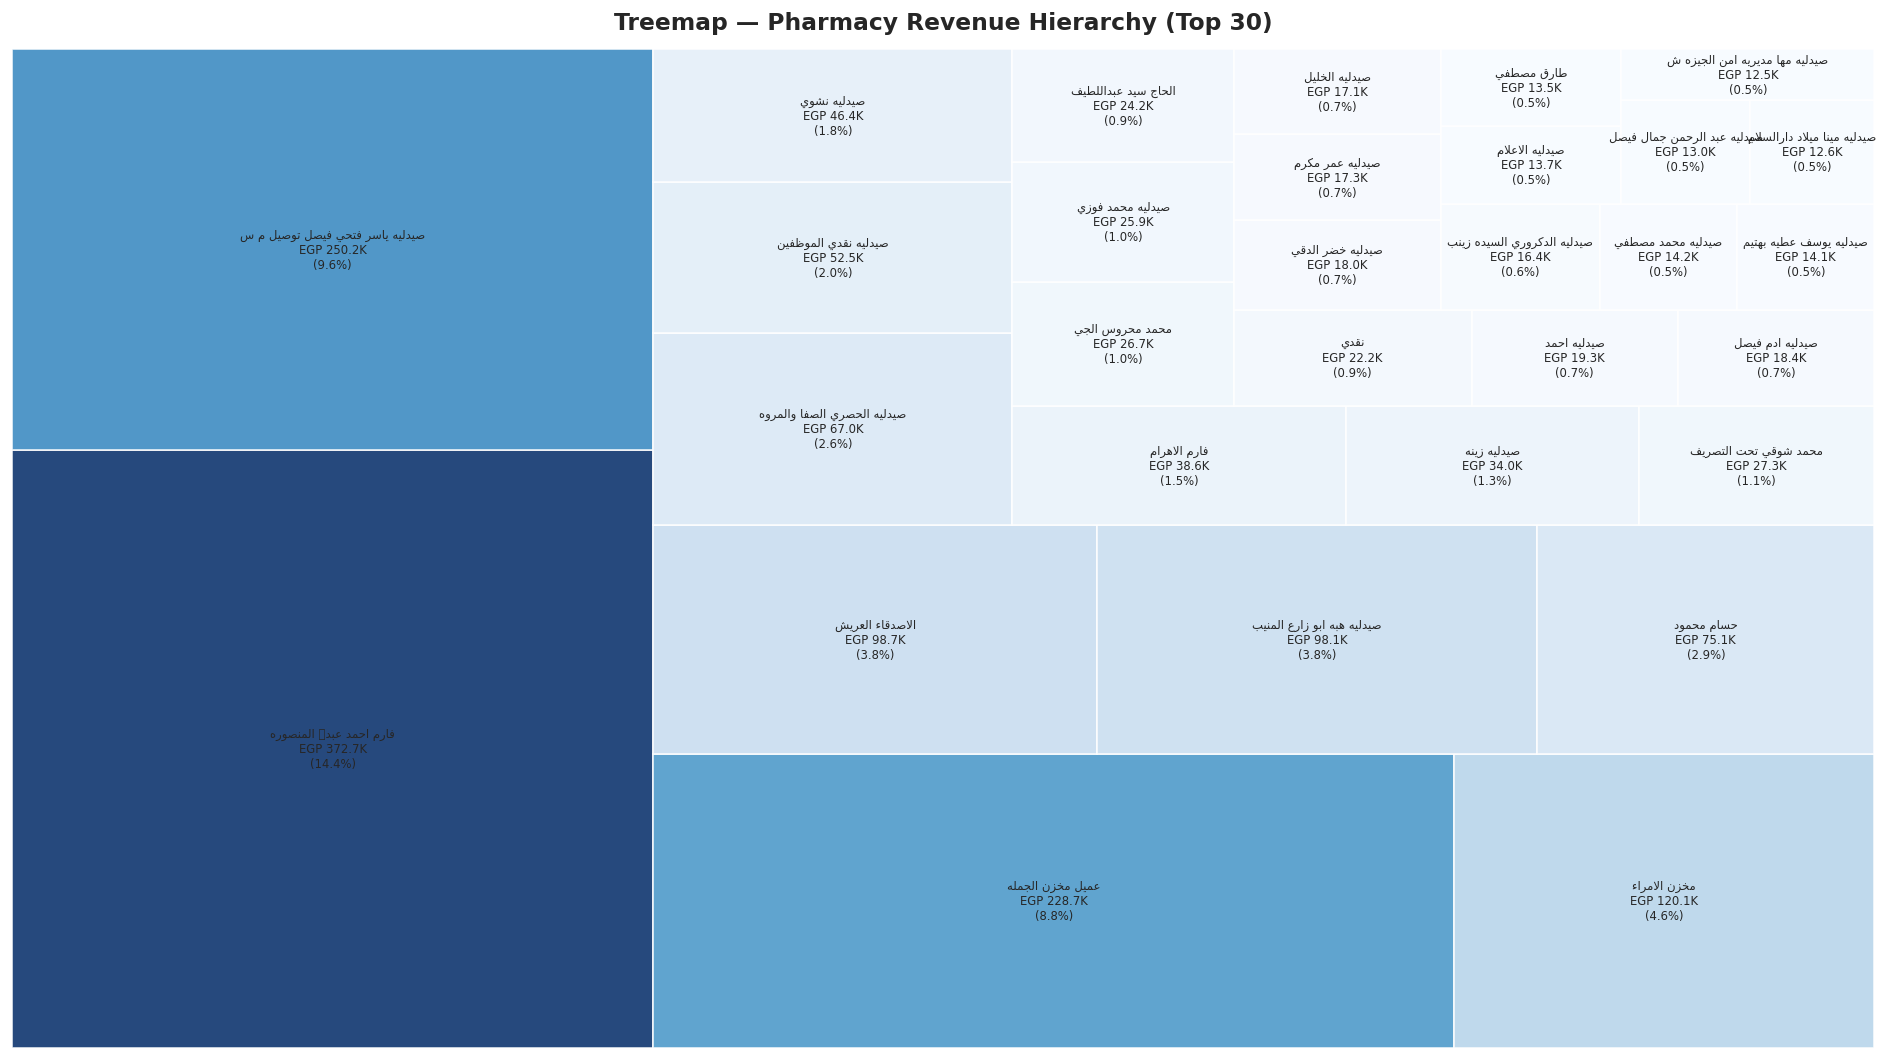

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

# 1. إعداد الخط (تأكد من وجود خط يدعم العربية على جهازك مثل Arial)
plt.rcParams['font.sans-serif'] = ['Arial']

# 2. دالة معالجة النصوص العربية
def get_arabic_text(text):
    return get_display(arabic_reshaper.reshape(str(text)))

# --- (بقية الكود الخاص بـ pharmacy_summary و invoice_df هنا) ---

# ── Fig 1: Top 10 Pharmacies (عدلناه هنا) ──
top10_plot = pharmacy_summary.head(10).sort_values("Total Revenue")
# معالجة الأسماء
top10_plot["Pharmacy Name Display"] = top10_plot["Pharmacy Name"].apply(get_arabic_text)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("Blues_d", len(top10_plot))
bars = ax.barh(top10_plot["Pharmacy Name Display"], top10_plot["Total Revenue"], color=colors, edgecolor="white")

for bar, val, pct in zip(bars, top10_plot["Total Revenue"], top10_plot["Revenue Contribution %"]):
    ax.text(bar.get_width() + TOTAL_REVENUE * 0.003,
            bar.get_y() + bar.get_height() / 2,
            f"EGP {val:,.0f} ({pct:.1f}%)",
            va="center", fontsize=9, color="#333")

ax.set_xlabel("Total Revenue (EGP)", fontsize=11)
ax.set_title("Top 10 Pharmacies by Revenue", fontsize=14, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"EGP {x/1e3:.0f}K"))
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ── Fig 6: Treemap (النسخة النهائية للـ Treemap) ──
if HAS_SQUARIFY:
    top30 = pharmacy_summary.head(30).copy()
    fig, ax = plt.subplots(figsize=(16, 9))
    cmap = plt.get_cmap("Blues")
    norm = plt.Normalize(top30["Total Revenue"].min(), top30["Total Revenue"].max())
    colors = [cmap(norm(v)) for v in top30["Total Revenue"]]

    # معالجة النصوص داخل الـ Labels
    labels = [
        f"{get_arabic_text(row['Pharmacy Name'])}\nEGP {row['Total Revenue']/1e3:.1f}K\n({row['Revenue Contribution %']:.1f}%)"
        for _, row in top30.iterrows()
    ]

    import squarify
    squarify.plot(
        sizes=top30["Total Revenue"],
        label=labels,
        color=colors,
        alpha=0.88,
        ax=ax,
        text_kwargs={"fontsize": 7, "wrap": True},
    )
    ax.set_title("Treemap — Pharmacy Revenue Hierarchy (Top 30)", fontsize=14, fontweight="bold", pad=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 9. Export Deliverables

In [43]:
import os

OUTPUT_DIR = "pharmacy_analysis_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Pharmacy Summary
pharmacy_summary.to_csv(f"{OUTPUT_DIR}/01_pharmacy_summary.csv", index=False, encoding="utf-8-sig")

# 2. Pharmacy–Supplier Revenue Table
pharm_sup.to_csv(f"{OUTPUT_DIR}/02_pharmacy_supplier_revenue.csv", index=False, encoding="utf-8-sig")

# 3. Pharmacy Invoice Detail Table
pharm_invoice_detail.to_csv(f"{OUTPUT_DIR}/03_pharmacy_invoice_detail.csv", index=False, encoding="utf-8-sig")

# 4. Move charts into output folder
import shutil
for fn in ["fig1_top10_bar.png","fig2_histogram.png","fig3_stacked_bar.png",
           "fig4_heatmap.png","fig5_pareto.png","fig6_treemap.png","fig6_pie_fallback.png"]:
    if os.path.exists(fn):
        shutil.copy(fn, f"{OUTPUT_DIR}/{fn}")

print("All files saved to:", OUTPUT_DIR)
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f"{OUTPUT_DIR}/{f}")
    print(f"  {f:50s}  {size/1024:>8.1f} KB")


All files saved to: pharmacy_analysis_output
  01_pharmacy_summary.csv                                 98.6 KB
  02_pharmacy_supplier_revenue.csv                        69.8 KB
  03_pharmacy_invoice_detail.csv                         238.3 KB
  fig1_top10_bar.png                                     109.9 KB
  fig2_histogram.png                                     101.2 KB
  fig3_stacked_bar.png                                   154.4 KB
  fig4_heatmap.png                                       146.8 KB
  fig5_pareto.png                                         95.0 KB
  fig6_treemap.png                                       198.7 KB


## Executive Summary

### Key Findings

| Metric | Value |
|--------|-------|
| **Total Dataset Revenue** | EGP 2,593,247 |
| **Total Pharmacies** | 1,085 |
| **Total Unique Invoices** | 2,937 |
| **Active Suppliers** | 10 |

### Revenue Concentration (Pareto)
- The **top 10 pharmacies** (< 1% of all pharmacies) account for **~54% of total revenue**.
- Just **68 pharmacies (6.3%)** generate **80% of total revenue** — a highly concentrated distribution.

### Top 5 Revenue Pharmacies
1. **فارم احمد عبدالله المنصوره** — EGP 372,736 (14.4%)
2. **صيدليه ياسر فتحي فيصل توصيل م س** — EGP 250,231 (9.6%)
3. **عميل مخزن الجمله** — EGP 228,750 (8.8%)
4. **مخزن الامراء** — EGP 120,148 (4.6%)
5. **الاصدقاء العريش** — EGP 98,742 (3.8%)

### Top Suppliers (Dataset-Wide)
| Rank | Supplier ID | Revenue (EGP) |
|------|-------------|---------------|
| 1 | 80 | 595,473 |
| 2 | 76 | 458,462 |
| 3 | 72 | 347,988 |
| 4 | 75 | 329,085 |
| 5 | 63 | 252,679 |

### Strategic Recommendations
1. **Prioritise top-10 accounts** — their combined revenue exceeds half the portfolio; any churn is disproportionately costly.
2. **Investigate single-supplier pharmacies** — over-reliance on one supplier creates supply risk; cross-selling opportunities exist.
3. **Target the long tail** — 1,015 pharmacies generate the remaining ~46% of revenue; targeted campaigns could improve wallet share.
4. **Supplier 80 dominance** — Supplier 80 leads revenue; evaluate exclusive arrangements or volume discounts to protect this relationship.
